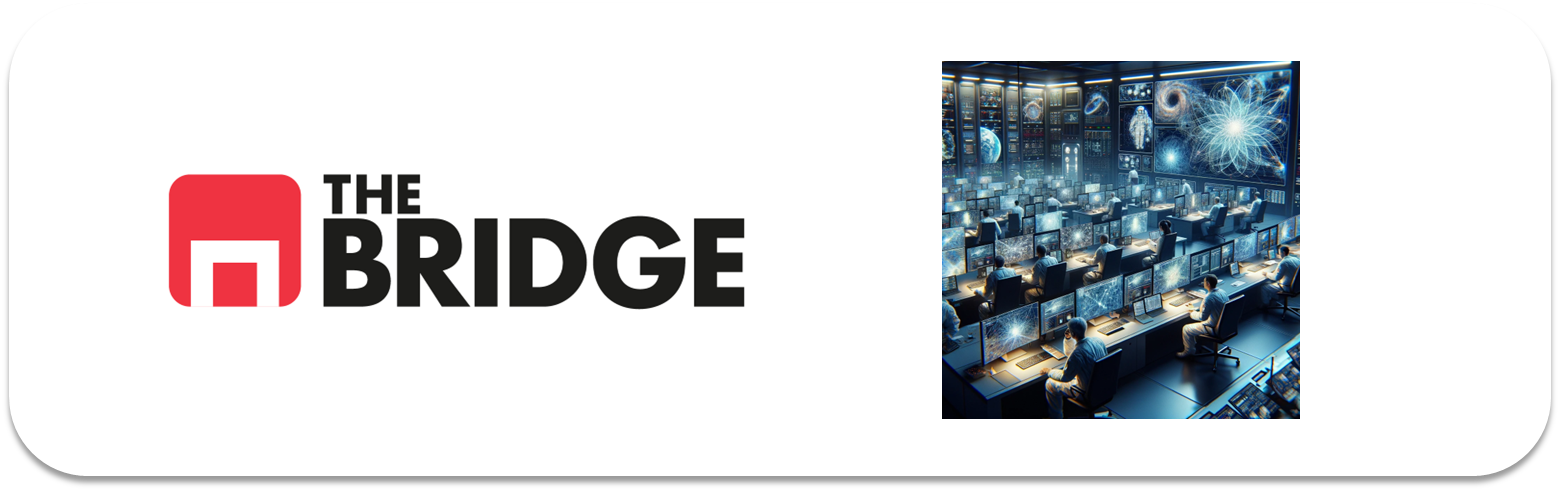

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [10]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

from PIL import Image # Para leer y redimensionar imágenes
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from bootcampviztools import pinta_distribucion_categoricas

from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPool2D
from keras.layers import Dropout
from keras.layers import Flatten, Dense
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



**1. Creación de datasets:**

In [38]:
IMG_SIZE = (32, 32) # Tamaño pedido

def leer_imagenes_directorio(directorios, img_size=IMG_SIZE):
    """
    Lee todas las imágenes JPG/PNG de una lista de directorios,
    las redimensiona a img_size y extrae la etiqueta del nombre de archivo.

    Convenio de nombres (igual que en datasets de Kaggle):
    cat.XXXX.jpg  ->  clase 0  (gato)
    dog.XXXX.jpg  ->  clase 1  (perro)

    Devuelve:
        X : np.ndarray float32 (N, alto, ancho, 3), valores en [0,1]
        y : np.ndarray int32 (N,)
        nombres : list[str] nombres de archivo (útil para el punto 5)
    """
    imagenes, etiquetas, nombres = [], [], []

    for directorio in directorios:
        rutas = []
        for ext in ('*.jpg', '*.jpeg', '*.png'):
            rutas += glob.glob(os.path.join(directorio, ext))
        print(f'  Directorio: {directorio} - {len(rutas)} imágenes encontradas')

        for ruta in rutas:
            nombre = os.path.basename(ruta).lower()

            # Determinamos la clase a partir del nombre del archivo
            if nombre.startswith('cat'):
                etiqueta = 0
            elif nombre.startswith('dog'):
                etiqueta = 1
            else:
                # Búsqueda más clara por si el nombre no empieza exactamente por cat/dog
                if 'cat' in nombre:
                    etiqueta = 0
                elif 'dog' in nombre:
                    etiqueta = 1
                else:
                    print(f'No se pudo determinar la clase de: {nombre}')
                    continue

            try:
                img = Image.open(ruta).convert('RGB') # Forzamos 3 canales (RGB)
                img = img.resize(img_size) # Redimensionamos a 32x32
                imagenes.append(np.array(img))
                etiquetas.append(etiqueta)
                nombres.append(nombre)
            except Exception as e:
                print(f'Error leyendo {nombre}: {e}')

    X = np.array(imagenes, dtype='float32')
    y = np.array(etiquetas, dtype='int32')
    return X, y, nombres

In [ ]:
TRAIN_DIRS = [
    'data/github_train_0',
    'data/github_train_1',
    'data/github_train_2', 
    'data/github_train_3',
]
TEST_DIRS = ['data/github_test']

# split:
X_train, y_train, nombres_train = leer_imagenes_directorio(TRAIN_DIRS)
X_test, y_test, nombres_test = leer_imagenes_directorio(TEST_DIRS)

print(f'\nX_train shape: {X_train.shape}   y_train shape: {y_train.shape}')
print(f'X_test  shape: {X_test.shape}    y_test  shape: {y_test.shape}')

  Directorio: data/github_train_0  →  1000 imágenes encontradas
  Directorio: data/github_train_1  →  1000 imágenes encontradas
  Directorio: data/github_train_2  →  1000 imágenes encontradas
  Directorio: data/github_train_3  →  1000 imágenes encontradas
  Directorio: data/github_test  →  1000 imágenes encontradas

X_train shape: (4000, 32, 32, 3)   y_train shape: (4000,)
X_test  shape: (1000, 32, 32, 3)    y_test  shape: (1000,)


Rango de valores de píxel: [0, 1]  <- escala 0-255, RGB
Dtype: float32


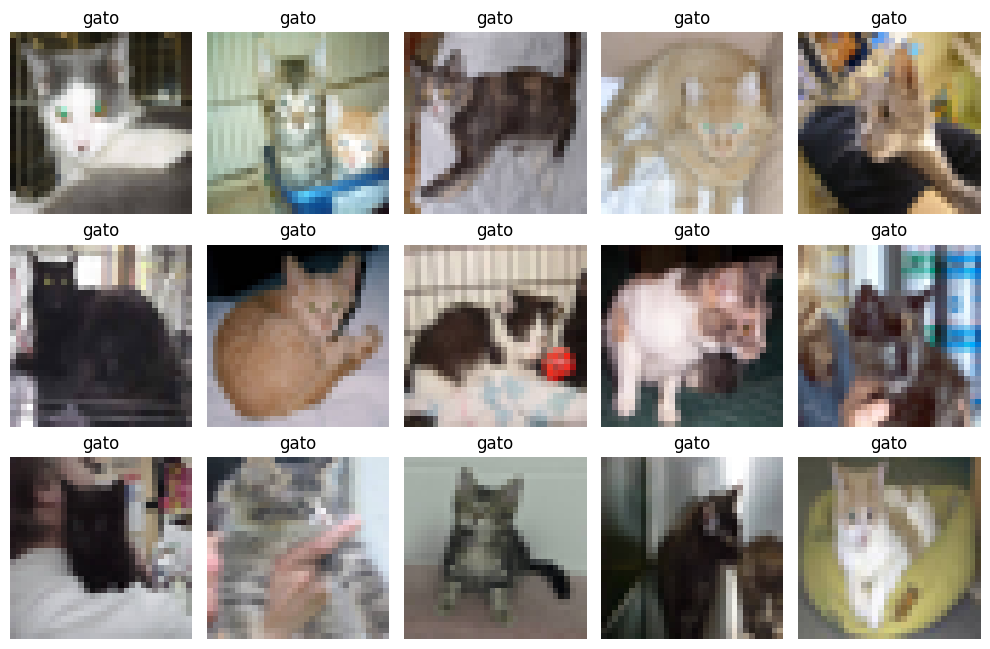

In [11]:
# Primera inspección — igual que en clase hacíamos df.head() y df.info()
print(f'Rango de valores de píxel: [{X_train.min():.0f}, {X_train.max():.0f}]  <- escala 0-255, RGB')
print(f'Dtype: {X_train.dtype}')

# Visualizamos una muestra, igual que en clase con plot_digits
plot_images(X_train[0:15], y_train[0:15])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [11.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [13.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [8.0..225.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [52.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [23.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..208.0].
Clipping input data to the valid range for imshow with RGB

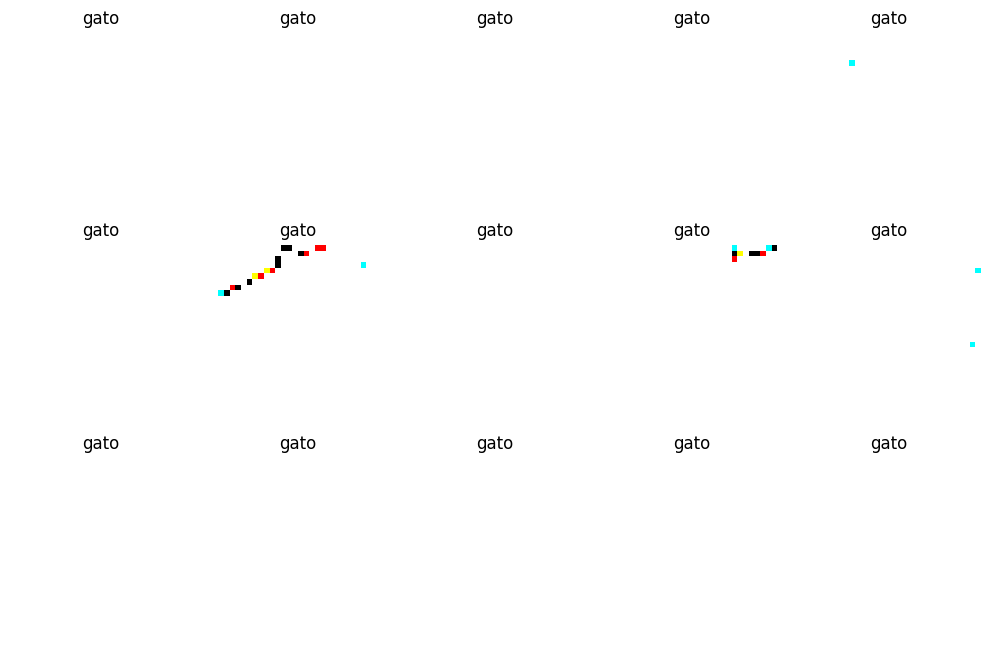

In [5]:
def plot_images(images, labels=[], names=['gato', 'perro'], n_cols=5):
    """
    Acepta arrays de numpy con forma (N, alto, ancho, 3).
    Los valores pueden estar en [0, 1] o [0, 255]: imshow los maneja bien.
    """
    n_rows = (len(images) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols * 2, n_rows * 2.2))
    for index, img in enumerate(images):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(img)          # RGB, no hace falta cmap
        plt.axis('off')
        if len(labels):
            if isinstance(labels, pd.Series):
                plt.title(names[labels.iloc[index]])
            else:
                plt.title(names[labels[index]])
    plt.tight_layout()
    plt.show();

# Visualizamos una muestra del train, igual que en clase
plot_images(X_train[0:15], y_train[0:15])

**2. Mini-EDA + construcción de modelo CNN:**

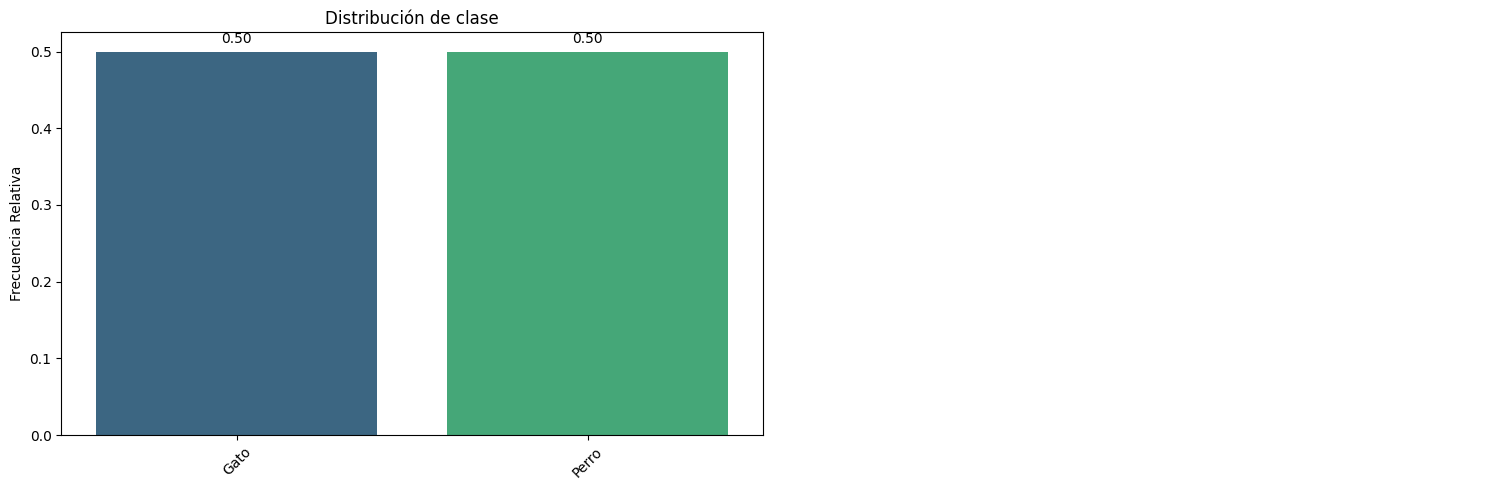

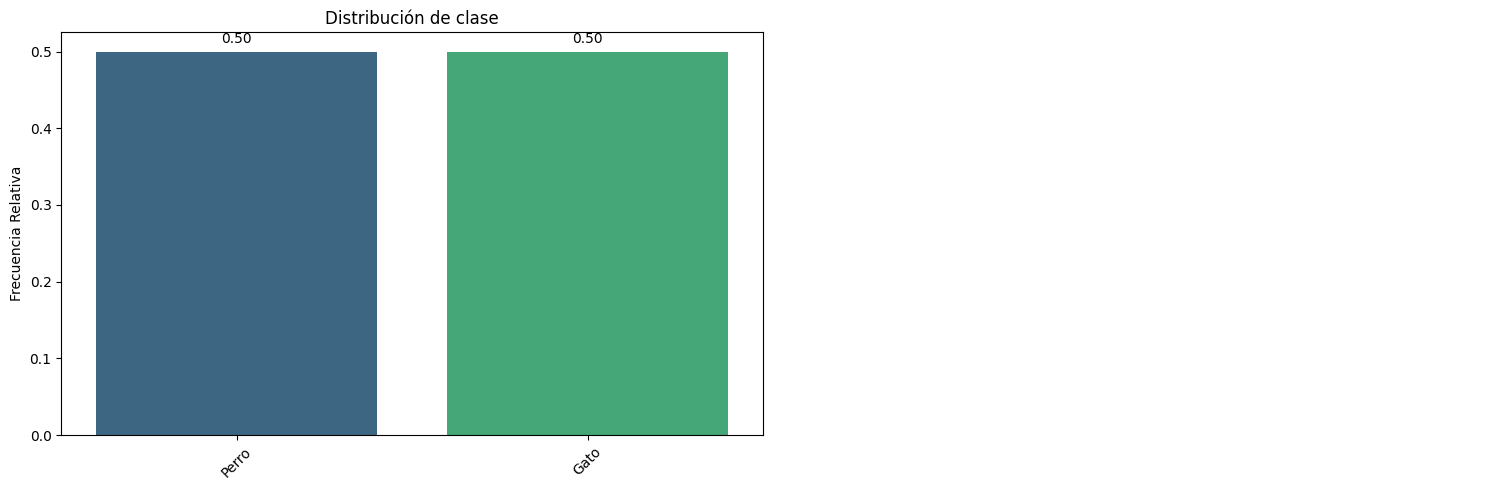

In [13]:
target = 'clase'

# Construimos un df con el target, igual que en clase teníamos train_set con la columna 'label'
# Mapeamos 0 -> 'Gato' y 1 -> 'Perro' para que los gráficos sean legibles
train_df_eda = pd.DataFrame({target: pd.Series(y_train).map({0: 'Gato', 1: 'Perro'})})
test_df_eda  = pd.DataFrame({target: pd.Series(y_test).map({0: 'Gato',  1: 'Perro'})})

pinta_distribucion_categoricas(train_df_eda, [target], relativa=True, mostrar_valores=True)
pinta_distribucion_categoricas(test_df_eda,  [target], relativa=True, mostrar_valores=True)

El dataset está muy bien equilibrado, podemos usar accuracy como métrica principal.

**Transformación de features:**

Rango de valores tras escalar: [0.0, 1.0]
X_train shape: (4000, 32, 32, 3) - (N_muestras, alto, ancho, canales_RGB)


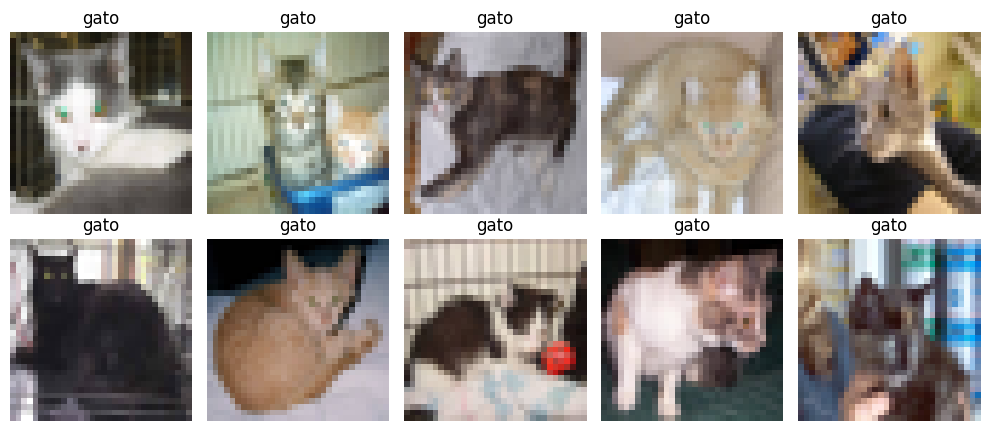

In [9]:
# Escalado: dividimos entre 255 (valor máximo de píxel en escala RGB)
# X_train = train_set.drop(target, axis=1) / 255
X_train = X_train / 255.0
X_test  = X_test  / 255.0

print(f'Rango de valores tras escalar: [{X_train.min():.1f}, {X_train.max():.1f}]')
print(f'X_train shape: {X_train.shape} - (N_muestras, alto, ancho, canales_RGB)')

# Verificamos que el plot sigue funcionando después del escalado (igual que en clase)
plot_images(X_train[0:10], y_train[0:10])

**Construcción de modelo DL con redes convolucionales:**

In [ ]:
# 1. Topología: definimos el modelo:

model = Sequential()

In [15]:
# primera capa convolucional:

model.add(Conv2D(filters=8, kernel_size=(5, 5), padding='Same',
                 activation='relu', input_shape=(32, 32, 3))) # Pesos: 8 * (5*5*3 + 1) = 8 * 76 = 608  (el *3 es por los 3 canales RGB)
# Resolución de salida: stride(1,1) + padding='Same' -> 32x32
print('Pesos capa Conv1:', 8 * (5 * 5 * 3 + 1))
print('Features a la salida:', 32 * 32 * 8)

Pesos capa Conv1: 608
Features a la salida: 8192


In [16]:
# primera capa de maxpooling:

model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2))) # Sin pesos entrenables (operación fija: tomar el máximo)
print('Features tras MaxPool1:', 16 * 16 * 8) # Resolución de salida: 32/2 x 32/2 x 8 = 16x16x8 = 2048 features

Features tras MaxPool1: 2048


In [17]:
# primera capa de dropout:

model.add(Dropout(rate=0.25))

In [18]:
# segundo bloque: conv, maxpool, dropout:

model.add(Conv2D(filters=16, kernel_size=(3, 3), padding='Same', activation='relu'))
# Stride(1,1) + padding='Same' -> resolución igual: 16x16

model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
# Resolución de salida: 16/2 x 16/2 x 16 = 8x8x16 = 1024 features

model.add(Dropout(0.25))

print('Features tras Bloque 2:', 8 * 8 * 16)

Features tras Bloque 2: 1024


In [19]:
# cabeza densa: flatten aplana los 8x8x16 = 1024 features en un vector 1D:

print('Entrada de la capa Flatten:', model.output_shape)
model.add(Flatten())
print('Salida de la capa Flatten :', model.output_shape)

model.add(Dense(256, activation='relu'))
# Pesos: (8*8*16 + 1) * 256 = 262.400

model.add(Dropout(0.5))

# Salida: 2 unidades con softmax (gato / perro)
# Igual que en clase pero con 2 en vez de 10 (tenemos 2 clases, no 10 dígitos)
model.add(Dense(2, activation='softmax'))
# Pesos: (256 + 1) * 2 = 514

Entrada de la capa Flatten: (None, 8, 8, 16)
Salida de la capa Flatten : (None, 1024)


In [ ]:
# 2. optimizador:

optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

In [ ]:
# 3. compilación:

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy', # porque las etiquetas son enteros simples (0 y 1)
    metrics=['accuracy'] # porque el dataset esta equilibrado
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 8)      │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 264,690 (1.01 MB)

 Trainable params: 264,690 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

**3. Entrenar con EarlyStopping y mostrar historial:**

In [ ]:
from keras.callbacks import EarlyStopping

batch_size= 128
epochs= 50 # Máximo alto; EarlyStopping parará antes si no mejora
validation_split= 0.2

early_stop = EarlyStopping(
    monitor='val_loss', # Vigila la pérdida en validación
    patience=5, # Para si en 5 epochs seguidas no mejora
    restore_best_weights=True, # Recupera los pesos del mejor epoch al terminar
    verbose=1
)

history = model.fit(
    X_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=validation_split,
    callbacks=[early_stop]
)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.6200 - loss: 0.6783 - val_accuracy: 0.0000e+00 - val_loss: 0.8062
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6228 - loss: 0.6611 - val_accuracy: 0.0000e+00 - val_loss: 0.8432
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6278 - loss: 0.6532 - val_accuracy: 0.0000e+00 - val_loss: 0.8858
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6325 - loss: 0.6438 - val_accuracy: 0.2075 - val_loss: 0.7901
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6519 - loss: 0.6287 - val_accuracy: 0.2025 - val_loss: 0.8264
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6528 - loss: 0.6148 - val_accuracy: 0.3338 - val_loss: 0.8252
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6603 - loss: 0.6132 - val_accuracy: 0.4437 - val_loss: 0.7556
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6756 - loss: 0.5994 - val_accuracy

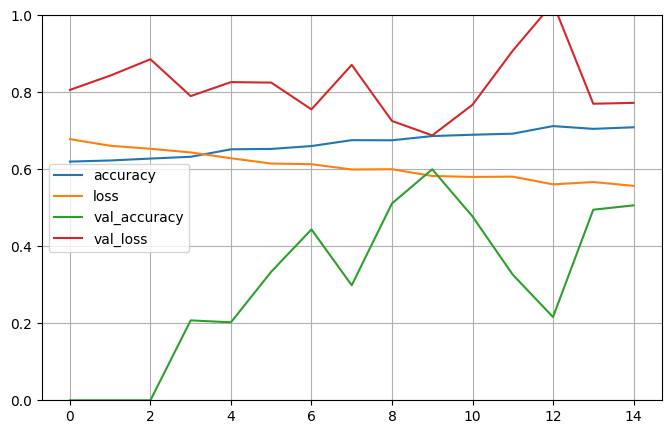

In [37]:
# vemos la evolución del entrenamiento en función de los epochs:

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show();

In [36]:
# lo ponemos en un df:
history_df

,accuracy,loss,val_accuracy,val_loss
0,0.620000,0.678331,0.00000,0.806158
1,0.622813,0.661089,0.00000,0.843216
2,0.627813,0.653212,0.00000,0.885773
3,0.632500,0.643764,0.20750,0.790085
4,0.651875,0.628693,0.20250,0.826374
5,0.652812,0.614833,0.33375,0.825158
6,0.660312,0.613214,0.44375,0.755582
7,0.675625,0.599433,0.29875,0.871205
8,0.675313,0.600134,0.51125,0.725468
9,0.686250,0.582563,0.60000,0.688045


**4. Evaluar modelo:**

In [26]:
model.evaluate(X_test, y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6680 - loss: 0.6145


[0.6145133376121521, 0.6679999828338623]

In [27]:
# np.argmax sobre las predicciones de probabilidad
# model.predict devuelve [P(gato), P(perro)] para cada imagen
predicciones = model.predict(X_test)
y_pred = [np.argmax(pred) for pred in predicciones]

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [28]:
# classification report:

print(classification_report(y_test, y_pred, target_names=['Gato', 'Perro']))

              precision    recall  f1-score   support

        Gato       0.64      0.75      0.69       500
       Perro       0.70      0.58      0.64       500

    accuracy                           0.67      1000
   macro avg       0.67      0.67      0.67      1000
weighted avg       0.67      0.67      0.67      1000



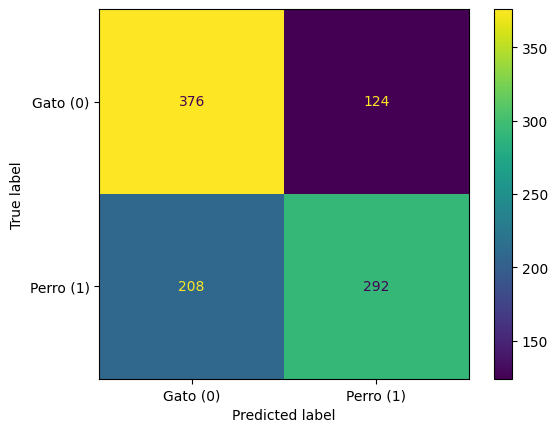

In [29]:
# vemos la matriz de confusión:

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Gato (0)', 'Perro (1)']
)
plt.show()

Resultados:
- el modelo predice mejor a los perros que a los gatos.
- Sin embargo, de todos los gatos, predice correctamente el 75%, frente a la predicción correcta de perros, que es un 58%.
- El F1-score es ligeramente más alto en gatos que en perros. 
- El modelo predice ambas clases de forma similar.

**Matriz de confusión:**
- De los gatos, predice correctamente 376 frente al 124 que predice como perro (pero es gato).
- De los perros, predice correctamente 29 frente a los 208 que predice como gato (pero es perro).

**5. Seleccionar 10% de imágenes más difíciles para el captcha:**

In [30]:
# Construimos un DataFrame con toda la info
df_test = pd.DataFrame({
    'nombre'     : nombres_test,
    'clase_real' : y_test,
    'clase_pred' : y_pred,
    'prob_gato'  : predicciones[:, 0],   # P(gato)  — columna 0 de predict
    'prob_perro' : predicciones[:, 1],   # P(perro) — columna 1 de predict
    'correcto'   : (y_test == y_pred)
})

print(f'Total imágenes test       : {len(df_test)}')
print(f'Correctamente clasificadas: {df_test["correcto"].sum()}')
print(f'Mal clasificadas          : {(~df_test["correcto"]).sum()}')
df_test.head()

Total imágenes test       : 1000
Correctamente clasificadas: 668
Mal clasificadas          : 332


,nombre,clase_real,clase_pred,prob_gato,prob_perro,correcto
0,dog.9469.jpg,1,0,0.568765,0.431235,False
1,dog.8763.jpg,1,1,0.381549,0.618451,True
2,dog.9455.jpg,1,0,0.629665,0.370335,False
3,cat.11515.jpg,0,0,0.582438,0.417562,True
4,dog.9496.jpg,1,1,0.435088,0.564912,True


In [31]:
# primer grupo: perros clasificados como gatos:

perros_como_gatos = df_test[
    (df_test['clase_real'] == 1) & # son perros de verdad...
    (df_test['clase_pred'] == 0) # ...pero el modelo dijo gato
].copy()

# Ordenamos por prob_gato descendente: mayor confianza en el error primero
perros_como_gatos = perros_como_gatos.sort_values('prob_gato', ascending=False)

n_perros_captcha = max(1, int(np.ceil(len(perros_como_gatos) * 0.10)))
top_perros = perros_como_gatos.head(n_perros_captcha)

print(f'Perros clasificados como Gatos: {len(perros_como_gatos)}')
print(f'Seleccionados para CAPTCHA (10%): {n_perros_captcha}')
print()
print(top_perros[['nombre', 'prob_gato', 'prob_perro']])

Perros clasificados como Gatos: 208
Seleccionados para CAPTCHA (10%): 21

           nombre  prob_gato  prob_perro
177  dog.8764.jpg   0.983142    0.016858
399  dog.8882.jpg   0.915526    0.084474
746  dog.8533.jpg   0.908252    0.091748
440  dog.9631.jpg   0.906151    0.093849
54   dog.8979.jpg   0.905685    0.094315
106  dog.9457.jpg   0.894730    0.105270
527  dog.8696.jpg   0.858926    0.141074
873  dog.8542.jpg   0.847386    0.152614
289  dog.8477.jpg   0.846475    0.153525
626  dog.9367.jpg   0.822342    0.177659
738  dog.9765.jpg   0.819010    0.180990
616  dog.9617.jpg   0.818691    0.181309
931  dog.8547.jpg   0.818084    0.181916
587  dog.8859.jpg   0.812255    0.187745
446  dog.8507.jpg   0.807706    0.192294
6    dog.8213.jpg   0.789418    0.210582
806  dog.8958.jpg   0.789089    0.210911
841  dog.8806.jpg   0.781430    0.218570
635  dog.9607.jpg   0.773689    0.226311
787  dog.8145.jpg   0.770157    0.229843
940  dog.8745.jpg   0.764400    0.235600


In [32]:
# segundo grupo: gatos clasificados como perros:

gatos_como_perros = df_test[
    (df_test['clase_real'] == 0) & # son gatos de verdad...
    (df_test['clase_pred'] == 1) # ...pero el modelo dijo perro
].copy()

gatos_como_perros = gatos_como_perros.sort_values('prob_perro', ascending=False)

n_gatos_captcha = max(1, int(np.ceil(len(gatos_como_perros) * 0.10)))
top_gatos = gatos_como_perros.head(n_gatos_captcha)

print(f'Gatos clasificados como Perros: {len(gatos_como_perros)}')
print(f'Seleccionados para CAPTCHA (10%): {n_gatos_captcha}')
print()
print(top_gatos[['nombre', 'prob_perro', 'prob_gato']])

Gatos clasificados como Perros: 124
Seleccionados para CAPTCHA (10%): 13

            nombre  prob_perro  prob_gato
247  cat.11511.jpg    0.732546   0.267454
691  cat.11550.jpg    0.725619   0.274380
356  cat.11164.jpg    0.718814   0.281186
693  cat.10882.jpg    0.716603   0.283397
495  cat.11572.jpg    0.716224   0.283776
300  cat.11985.jpg    0.715817   0.284183
448  cat.12330.jpg    0.710592   0.289408
575  cat.11636.jpg    0.699130   0.300870
262  cat.11760.jpg    0.698266   0.301734
566  cat.11018.jpg    0.691580   0.308420
79   cat.11462.jpg    0.689820   0.310180
882  cat.11240.jpg    0.679243   0.320757
627  cat.12074.jpg    0.676318   0.323682


In [35]:
# resultado final:

top_perros['grupo'] = 'perro_clasificado_como_gato'
top_gatos['grupo']  = 'gato_clasificado_como_perro'

df_captcha = pd.concat([top_perros, top_gatos], ignore_index=True)

print('IMÁGENES SELECCIONADAS PARA EL CAPTCHA')
print(f'Perros confundidos con gatos: {n_perros_captcha}')
print(f'Gatos confundidos con perros: {n_gatos_captcha}')
print(f'TOTAL: {len(df_captcha)}')
print()
df_captcha[['nombre', 'grupo', 'prob_gato', 'prob_perro']]

IMÁGENES SELECCIONADAS PARA EL CAPTCHA
Perros confundidos con gatos: 21
Gatos confundidos con perros: 13
TOTAL: 34



,nombre,grupo,prob_gato,prob_perro
0,dog.8764.jpg,perro_clasificado_como_gato,0.983142,0.016858
1,dog.8882.jpg,perro_clasificado_como_gato,0.915526,0.084474
2,dog.8533.jpg,perro_clasificado_como_gato,0.908252,0.091748
3,dog.9631.jpg,perro_clasificado_como_gato,0.906151,0.093849
4,dog.8979.jpg,perro_clasificado_como_gato,0.905685,0.094315
5,dog.9457.jpg,perro_clasificado_como_gato,0.894730,0.105270
6,dog.8696.jpg,perro_clasificado_como_gato,0.858926,0.141074
7,dog.8542.jpg,perro_clasificado_como_gato,0.847386,0.152614
8,dog.8477.jpg,perro_clasificado_como_gato,0.846475,0.153525
9,dog.9367.jpg,perro_clasificado_como_gato,0.822342,0.177659
